In [2]:
# ==========================================
#  Imports & Setup
# ==========================================
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set visual styles
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# ==========================================
# Generate Punjab Road Dataset
# ==========================================
np.random.seed(42)
random.seed(42)

NUM_RECORDS = 1000

# Major Punjab Cities & Base Coordinates
CITIES = {
    'Ludhiana': {'lat': 30.9010, 'lon': 75.8573},
    'Amritsar': {'lat': 31.6340, 'lon': 74.8723},
    'Jalandhar': {'lat': 31.3260, 'lon': 75.5762},
    'Patiala': {'lat': 30.3398, 'lon': 76.3869},
    'Bathinda': {'lat': 30.2110, 'lon': 74.9455},
    'Mohali': {'lat': 30.6799, 'lon': 76.7221}
}

CATEGORIES = ['Pothole', 'Damaged Asphalt', 'Waterlogging', 'Missing Signage', 'Traffic Accident']
STATUSES = ['Open', 'In Progress', 'Resolved']
ROAD_TYPES = ['National Highway', 'State Highway', 'City Main Road', 'Rural Road']
SEVERITY = ['Low', 'Medium', 'High', 'Critical']

raw_data = []
start_date = datetime(2025, 1, 1)

for i in range(1, NUM_RECORDS + 1):
    city = random.choice(list(CITIES.keys()))
    center = CITIES[city]

    # Coordinates centered around Punjab cities + intentional noisy outliers for cleaning test
    if random.random() < 0.03: # 3% noise (outside Punjab boundaries)
        lat = 18.5204 # Maharashtra lat
        lon = 73.8567
    else:
        lat = center['lat'] + np.random.normal(0, 0.04)
        lon = center['lon'] + np.random.normal(0, 0.04)

    cat = random.choice(CATEGORIES)
    status = random.choice(STATUSES)
    road_type = random.choice(ROAD_TYPES)
    sev = random.choice(SEVERITY)

    created_dt = start_date + timedelta(days=random.randint(0, 500))
    accidents_reported = random.randint(0, 5) if cat == 'Traffic Accident' else random.randint(0, 2)
    days_open = random.randint(1, 45) if status != 'Resolved' else random.randint(1, 10)

    raw_data.append({
        'complaint_id': f"PB-2026-{10000 + i}",
        'district': city,
        'latitude': round(lat, 6) if random.random() > 0.02 else np.nan, # Introduce missing values
        'longitude': round(lon, 6) if random.random() > 0.02 else np.nan,
        'complaint_type': cat,
        'severity': sev,
        'road_type': road_type,
        'status': status,
        'accidents_reported': accidents_reported,
        'days_open': days_open,
        'created_date': created_dt.strftime('%Y-%m-%d')
    })

df_raw = pd.DataFrame(raw_data)
df_raw.to_csv('punjab_road_issues.csv', index=False)
print("Raw dataset 'punjab_road_issues.csv' generated with 1,000 records.")

Raw dataset 'punjab_road_issues.csv' generated with 1,000 records.


In [6]:
# ==========================================
# Data Cleaning & Preprocessing
# ==========================================
df = pd.read_csv('punjab_road_issues.csv')

print(f"Initial raw rows: {len(df)}")

# 1. Drop missing coordinates
df_clean = df.dropna(subset=['latitude', 'longitude']).copy()

# 2. Filter coordinates strictly within Punjab bounding box
PUNJAB_LAT_MIN, PUNJAB_LAT_MAX = 29.5, 32.5
PUNJAB_LON_MIN, PUNJAB_LON_MAX = 73.8, 76.9

in_punjab = (
    (df_clean['latitude'] >= PUNJAB_LAT_MIN) & (df_clean['latitude'] <= PUNJAB_LAT_MAX) &
    (df_clean['longitude'] >= PUNJAB_LON_MIN) & (df_clean['longitude'] <= PUNJAB_LON_MAX)
)
df_clean = df_clean[in_punjab].copy()

# 3. Datetime conversion & Feature Extraction
df_clean['created_date'] = pd.to_datetime(df_clean['created_date'])
df_clean['year'] = df_clean['created_date'].dt.year
df_clean['month'] = df_clean['created_date'].dt.month_name()
df_clean['is_monsoon'] = df_clean['created_date'].dt.month.isin([7, 8, 9]) # July-Sept

# 4. Feature Engineering: Road Priority Index (RPI)
sev_weights = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df_clean['sev_numeric'] = df_clean['severity'].map(sev_weights)
df_clean['RPI'] = round(
    (df_clean['sev_numeric'] * 0.4) +
    (df_clean['accidents_reported'] * 0.35) +
    (df_clean['days_open'] * 0.25), 2
)

print(f"Cleaned dataset rows: {len(df_clean)} (Removed missing/out-of-bound coordinates)")
df_clean.head()

Initial raw rows: 1000
Cleaned dataset rows: 937 (Removed missing/out-of-bound coordinates)


,complaint_id,district,latitude,longitude,complaint_type,severity,road_type,status,accidents_reported,days_open,created_date,year,month,is_monsoon,sev_numeric,RPI
0,PB-2026-10001,Mohali,30.699769,76.716569,Waterlogging,Medium,State Highway,Open,0,44,2026-01-13,2026,January,False,2,11.80
1,PB-2026-10002,Bathinda,30.236908,75.006421,Pothole,Medium,State Highway,Open,2,2,2025-09-16,2025,September,True,2,2.00
2,PB-2026-10003,Mohali,30.670534,76.712735,Damaged Asphalt,Low,City Main Road,In Progress,0,45,2026-01-24,2026,January,False,1,11.65
3,PB-2026-10004,Amritsar,31.697169,74.902997,Waterlogging,Critical,National Highway,Open,1,23,2025-02-19,2025,February,False,4,7.70
4,PB-2026-10005,Mohali,30.661121,76.743802,Pothole,High,National Highway,In Progress,2,40,2026-03-01,2026,March,False,3,11.90


In [7]:
# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================
print("=== DATASET SUMMARY ===")
print(df_clean.info())

print("\n=== KEY DESCRIPTIVE STATISTICS ===")
display(df_clean[['days_open', 'accidents_reported', 'RPI']].describe())

print("\n=== COMPLAINTS BY DISTRICT ===")
print(df_clean['district'].value_counts())

print("\n=== COMPLAINTS BY SEVERITY ===")
print(df_clean['severity'].value_counts())

=== DATASET SUMMARY ===
<class 'pandas.core.frame.DataFrame'>
Index: 937 entries, 0 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   complaint_id        937 non-null    object        
 1   district            937 non-null    object        
 2   latitude            937 non-null    float64       
 3   longitude           937 non-null    float64       
 4   complaint_type      937 non-null    object        
 5   severity            937 non-null    object        
 6   road_type           937 non-null    object        
 7   status              937 non-null    object        
 8   accidents_reported  937 non-null    int64         
 9   days_open           937 non-null    int64         
 10  created_date        937 non-null    datetime64[ns]
 11  year                937 non-null    int32         
 12  month               937 non-null    object        
 13  is_monsoon          937 non-nul

,days_open,accidents_reported,RPI
count,937.000000,937.000000,937.000000
mean,17.259338,1.311633,5.757898
std,13.773503,1.251923,3.520726
min,1.000000,0.000000,0.650000
25%,6.000000,0.000000,2.850000
50%,11.000000,1.000000,4.550000
75%,29.000000,2.000000,8.650000
max,45.000000,5.000000,14.600000



=== COMPLAINTS BY DISTRICT ===
district
Patiala      180
Mohali       160
Ludhiana     160
Jalandhar    153
Bathinda     151
Amritsar     133
Name: count, dtype: int64

=== COMPLAINTS BY SEVERITY ===
severity
Low         251
Medium      238
Critical    234
High        214
Name: count, dtype: int64


/tmp/ipykernel_496/1535393826.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='severity', y='RPI', palette='Reds', ax=axes[0, 1])


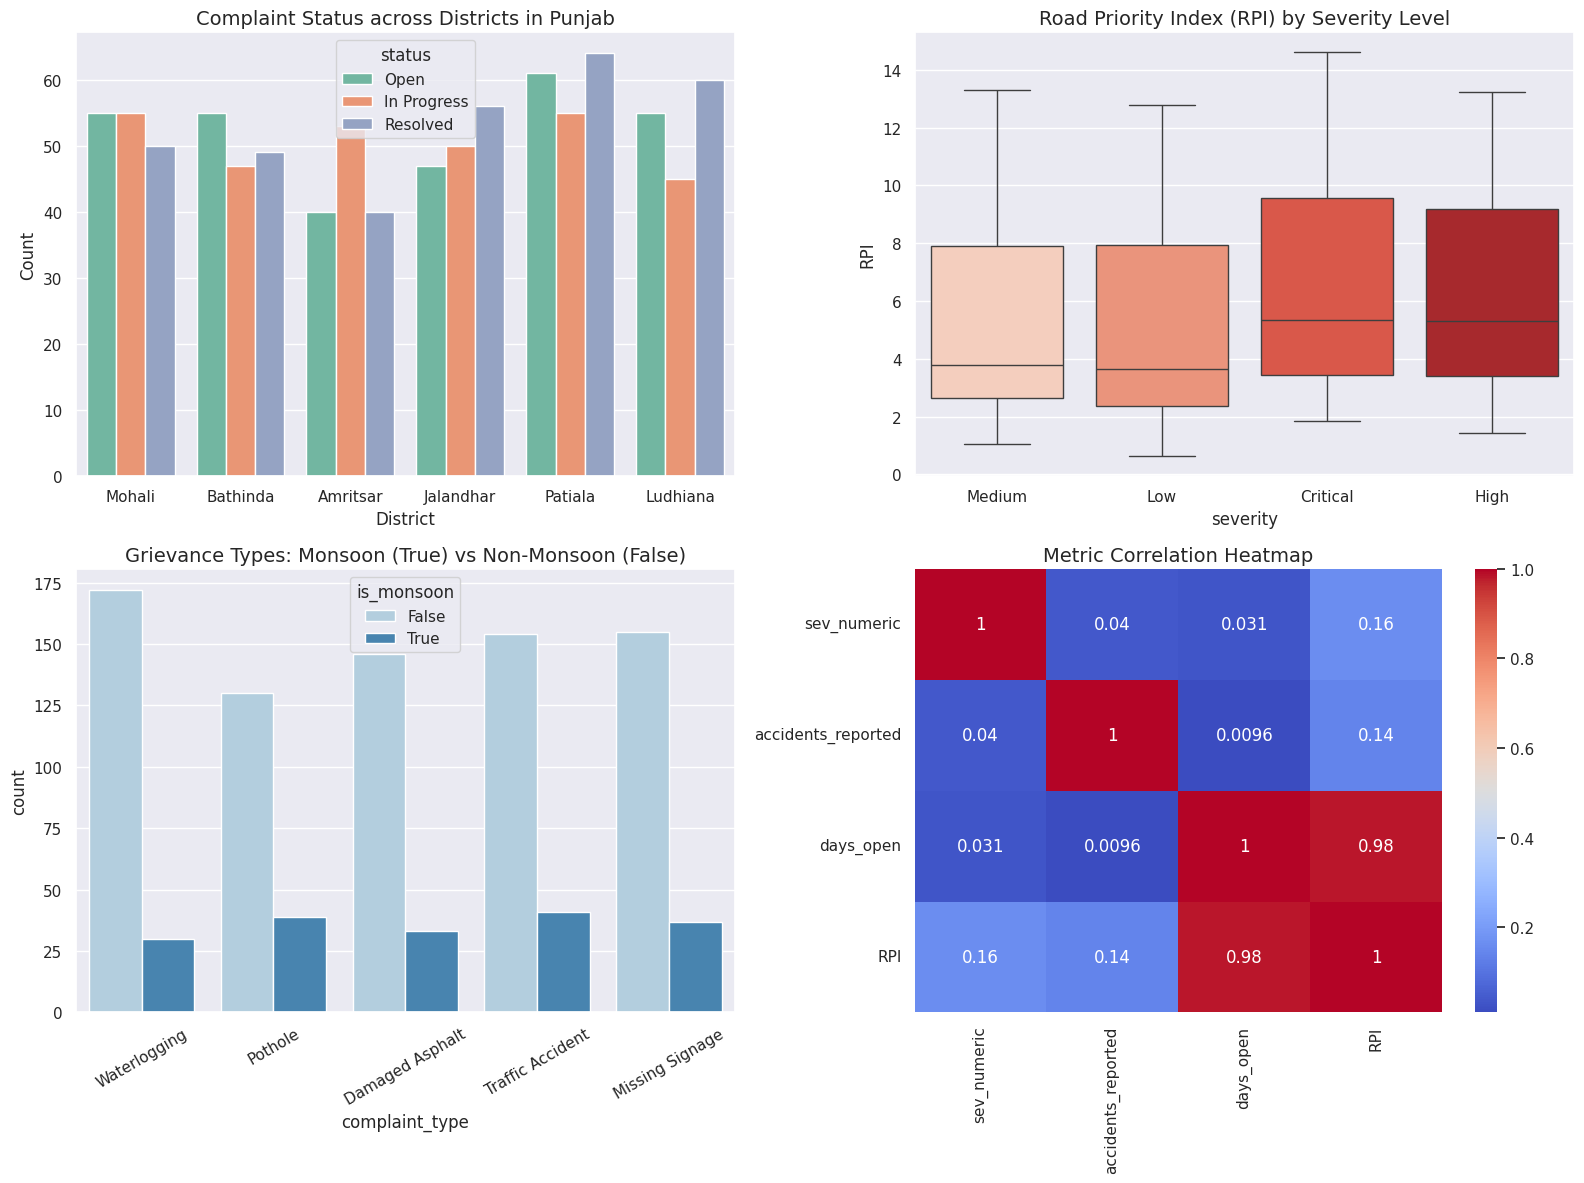

In [8]:
# ==========================================
#  Visualizations (Matplotlib & Seaborn)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total Complaints by District
sns.countplot(data=df_clean, x='district', hue='status', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title("Complaint Status across Districts in Punjab", fontsize=14)
axes[0, 0].set_xlabel("District")
axes[0, 0].set_ylabel("Count")

# 2. Road Priority Index Distribution
sns.boxplot(data=df_clean, x='severity', y='RPI', palette='Reds', ax=axes[0, 1])
axes[0, 1].set_title("Road Priority Index (RPI) by Severity Level", fontsize=14)

# 3. Monsoon vs Non-Monsoon Issues
sns.countplot(data=df_clean, x='complaint_type', hue='is_monsoon', palette='Blues', ax=axes[1, 0])
axes[1, 0].set_title("Grievance Types: Monsoon (True) vs Non-Monsoon (False)", fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Correlation Matrix
sns.heatmap(df_clean[['sev_numeric', 'accidents_reported', 'days_open', 'RPI']].corr(),
            annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title("Metric Correlation Heatmap", fontsize=14)

plt.tight_layout()
plt.show()

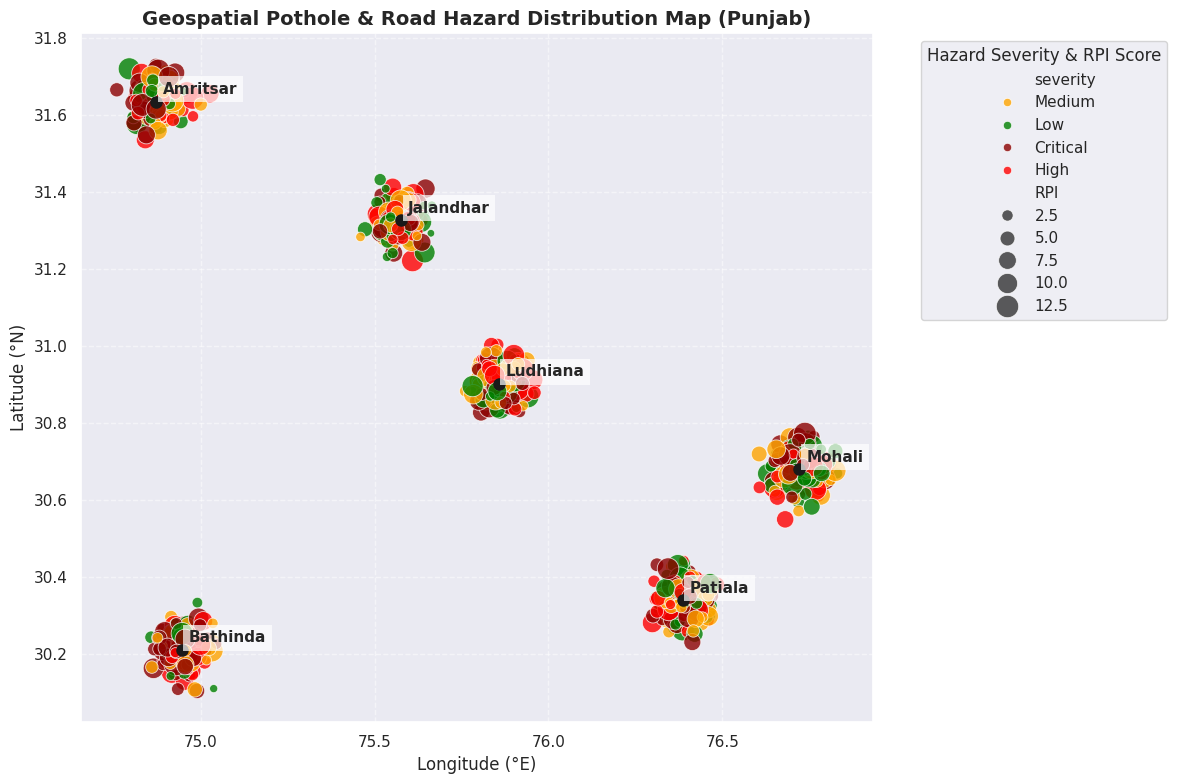

In [14]:
# ==========================================
#  Geospatial Map
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Scatter plot using real lat/long coordinates bounded over Punjab
scatter = sns.scatterplot(
    data=df_clean,
    x='longitude',
    y='latitude',
    hue='severity',
    size='RPI',
    sizes=(30, 300),
    palette={'Low': 'green', 'Medium': 'orange', 'High': 'red', 'Critical': 'darkred'},
    alpha=0.8
)

# Label Punjab major cities
city_centers = {
    'Ludhiana': (75.8573, 30.9010),
    'Amritsar': (74.8723, 31.6340),
    'Jalandhar': (75.5762, 31.3260),
    'Patiala': (76.3869, 30.3398),
    'Bathinda': (74.9455, 30.2110),
    'Mohali': (76.7221, 30.6799)
}

for city, (lon, lat) in city_centers.items():
    plt.plot(lon, lat, 'ko', markersize=8) # Black point for city center
    plt.text(lon + 0.02, lat + 0.02, city, fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title("Geospatial Pothole & Road Hazard Distribution Map (Punjab)", fontsize=14, fontweight='bold')
plt.xlabel("Longitude (°E)", fontsize=12)
plt.ylabel("Latitude (°N)", fontsize=12)
plt.legend(title="Hazard Severity & RPI Score", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()